In [1]:
from lenskit.datasets import ML1M
from lenskit import batch, topn, util
from lenskit import crossfold as xf
from lenskit.algorithms import Recommender, als, item_knn as knn
from lenskit import topn

In [2]:
import pandas as pd

In [3]:
%matplotlib inline

# GETTING STARTED DE LENSKIT PARA VERIFICAR SU USO CORRECTO

### Load Data

In [4]:
ml100k = ML1M('BBDD_1M')
ratings = ml100k.ratings
ratings.head()

,user,item,rating,timestamp
0,1,1193,5.0,978300760
1,1,661,3.0,978302109
2,1,914,3.0,978301968
3,1,3408,4.0,978300275
4,1,2355,5.0,978824291


### Defining Algorithms

In [5]:
algo_ii = knn.ItemItem(20)
algo_als = als.BiasedMF(50)

### Running the evaluation

In LensKit, our evaluation proceeds in 2 steps:

Generate recommendations

Measure them

If memory is a concern, we can measure while generating, but we will not do that for now.

We will first define a function to generate recommendations from one algorithm over a single partition of the data set. It will take an algorithm, a train set, and a test set, and return the recommendations.

Note: before fitting the algorithm, we clone it. Some algorithms misbehave when fit multiple times.

Note 2: our algorithms do not necessarily implement the Recommender interface, so we adapt them. This fills in a default candidate selector.

The code function looks like this:

In [6]:
def eval(aname, algo, train, test):
    fittable = util.clone(algo)
    fittable = Recommender.adapt(fittable)
    fittable.fit(train)
    users = test.user.unique()
    # now we run the recommender
    recs = batch.recommend(fittable, users, 100)
    # add the algorithm name for analyzability
    recs['Algorithm'] = aname
    return recs

Now, we will loop over the data and the algorithms, and generate recommendations:

In [7]:
ratings['user'] = ratings['user'].astype('int64')
ratings['item'] = ratings['item'].astype('int64')
all_recs = []
test_data = []
for train, test in xf.partition_users(ratings[['user', 'item', 'rating']], 5, xf.SampleFrac(0.2)):
    test_data.append(test)
    all_recs.append(eval('ItemItem', algo_ii, train, test))
    all_recs.append(eval('ALS', algo_als, train, test))

c:\Users\guill\anaconda3\Lib\site-packages\lenskit\algorithms\item_knn.py:119: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  b = blocks[bi]


With the results in place, we can concatenate them into a single data frame:

In [8]:
all_recs = pd.concat(all_recs, ignore_index=True)
all_recs.head()

,item,score,user,rank,Algorithm
0,3245,5.432447,8,1,ItemItem
1,2019,5.298249,8,2,ItemItem
2,439,5.191324,8,3,ItemItem
3,858,5.122811,8,4,ItemItem
4,3888,5.049450,8,5,ItemItem


To compute our analysis, we also need to concatenate the test data into a single frame:

In [9]:
test_data = pd.concat(test_data, ignore_index=True)

We analyze our recommendation lists with a RecListAnalysis. It takes care of the hard work of making sure that the truth data (our test data) and the recoommendations line up properly.

We do assume here that each user only appears once per algorithm. Since our crossfold method partitions users, this is fine.

In [10]:
rla = topn.RecListAnalysis()
rla.add_metric(topn.ndcg)
results = rla.compute(all_recs, test_data)
results.head()

nrecs      ndcg
Algorithm user                 
ItemItem  8       100  0.041843
          16      100  0.000000
          18      100  0.048446
          19      100  0.073890
          33      100  0.226530

Now we have nDCG values!

In [11]:
results.groupby('Algorithm').ndcg.mean()

Algorithm
ALS         0.102432
ItemItem    0.075272
Name: ndcg, dtype: float64

<Axes: xlabel='Algorithm'>

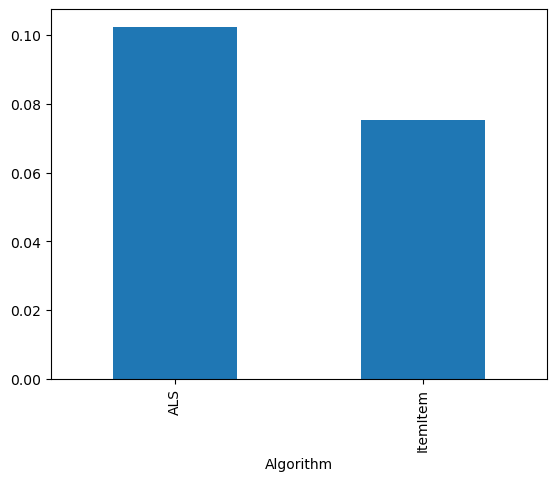

In [12]:
results.groupby('Algorithm').ndcg.mean().plot.bar()